# Phase 1: Business Understanding & Hypotheses

## Project Goal
Understanding the clinical and demographic factors influencing diabetes development to assist in early medical screening.

## Hypotheses to Test:
1. **Age & BMI:** Higher age combined with higher BMI strongly correlates with positive diabetes status.
2. **Clinical Tests:** `HbA1c_level` is the strongest overall clinical predictor for diabetes.
3. **Medical History:** Patients with `hypertension` or `heart_disease` have a higher incidence rate of diabetes.
4. **Lifestyle:** Active smoking history (`smoking_history`) increases the likelihood of being diabetic.
5. **Glucose Measure:** Patients with a `blood_glucose_level` $\ge 200 \text{ mg/dL}$ have an almost 100% chance of being diagnosed as diabetic (Clinical Diagnostic Criterion).

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("diabetes_prediction_dataset.csv")

print (f"dataset shape : {df.shape[0]} rows,{df.shape[1]} columns")
print ("-" * 50)

df.head()

dataset shape : 100000 rows,9 columns
--------------------------------------------------


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [3]:
#count values in smoking history
print(df['smoking_history'].value_counts())


#count values in gender
print(df['gender'].value_counts())

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64
gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64


In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
#drop gender where gender=other
df= df[df['gender']!='Other']

print (df['gender'].value_counts())

gender
Female    58552
Male      41430
Name: count, dtype: int64


In [6]:
smoking_mapping={
    'never' :'never',
    'current' :'current',
    'not current' :'former',
    'former' :'former',
    'ever' :'former',
    'No Info' :'No Info'
}

df['smoking_history']=df['smoking_history'].map(smoking_mapping)

print(df['smoking_history'].value_counts())

smoking_history
No Info    35810
never      35092
former     19794
current     9286
Name: count, dtype: int64


In [7]:
#filtering patient with high glucose level>200

above_200= df[df['blood_glucose_level']>=200]

#count true diabetic people in that level
glucose_insight=above_200['diabetes'].value_counts(normalize=True)*100

print(f"diabetic percentage in level >=200 ={glucose_insight}%")


diabetic percentage in level >=200 =diabetes
0    63.920559
1    36.079441
Name: proportion, dtype: float64%


In [8]:
#filtering patient with high HbA1c_level>6.5

above_6_5 = df[df['HbA1c_level']>=6.5]

#count true diabetic people in that level
HbA1c_insight =above_6_5['diabetes'].value_counts(normalize=True)*100

print(f"diabetic percentage in level >=200 ={HbA1c_insight}%")


diabetic percentage in level >=200 =diabetes
0    75.036068
1    24.963932
Name: proportion, dtype: float64%


In [9]:
#linking between age and diabetes by average

age_insight =df.groupby('diabetes')['age'].mean()
print(f"average age for diabetic categories= {age_insight}")

average age for diabetic categories= diabetes
0    40.117265
1    60.946588
Name: age, dtype: float64


In [10]:
#linking between age and BMI and diabetes by average

demographic_insight =df.groupby('diabetes')[['age','bmi']].mean()
print(f"average age, bmi for diabetic categories= {demographic_insight}")

average age, bmi for diabetic categories=                 age        bmi
diabetes                      
0         40.117265  26.887067
1         60.946588  31.988382


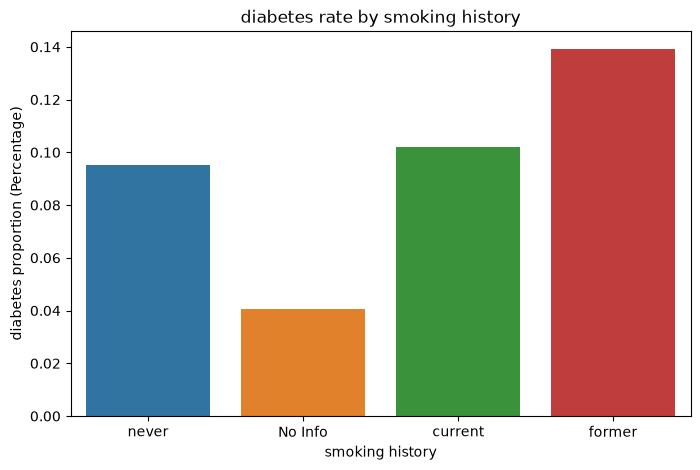

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 
#link smoking factor with diabetes by bar plot

plt.figure(figsize=(8, 5))
sns.barplot(x='smoking_history', y ='diabetes',hue='smoking_history', data=df, errorbar=None , legend=False)
plt.title('diabetes rate by smoking history')
plt.xlabel('smoking history')
plt.ylabel('diabetes proportion (Percentage)')
plt.show()


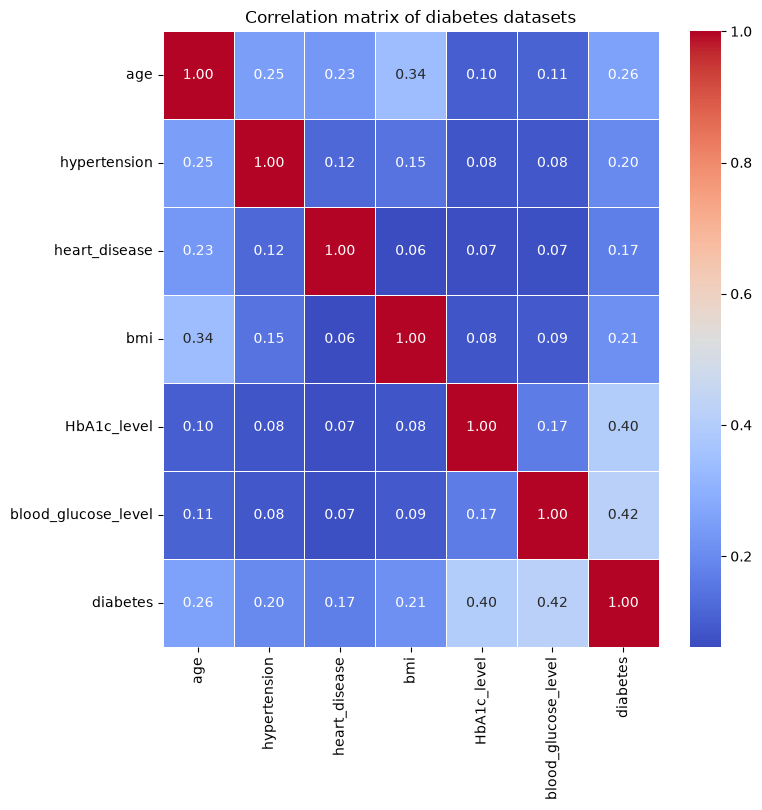

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns 

#heatmap to link between all factors

corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,8))
#annot=True


sns.heatmap(corr_matrix, annot=True , cmap= 'coolwarm', fmt=".2f" , linewidths= 0.5)
plt.title('Correlation matrix of diabetes datasets')
plt.show()

In [13]:
#machine learning
X = df[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']]

y=df['diabetes']
print("done")
print("X is: ",X.shape)
print("y is: ",y.shape)

done
X is:  (99982, 6)
y is:  (99982,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

print("(train):", X_train.shape[0])

print("(test):", X_test.shape[0])
print("ready okay")

(train): 79985
(test): 19997
ready okay


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(n_estimators=100 , random_state=42)

rf_model.fit(X_train,y_train)

print("ready")

ready


In [17]:
from sklearn.metrics import accuracy_score



rf_predictions=rf_model.predict(X_test)
rf_accuracy= accuracy_score(y_test, rf_predictions)
print(f"accuracy predication:{rf_accuracy*100:.2f}%")
print("ready okay")



accuracy predication:96.83%
ready okay


In [18]:
from sklearn.metrics import classification_report
#compare the orginat answers with the predicted ones


print(classification_report(y_test,rf_predictions))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18222
           1       0.92      0.70      0.80      1775

    accuracy                           0.97     19997
   macro avg       0.95      0.85      0.89     19997
weighted avg       0.97      0.97      0.97     19997



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
#encoding all columns

df_encoded= pd.get_dummies(df, columns=['gender','smoking_history'], drop_first=True)
x_full= df_encoded.drop(columns=['diabetes'])

y_full=df_encoded['diabetes']



X_train_f, X_test_f, y_train_f, y_test_f=train_test_split(x_full,y_full,test_size=0.2, random_state=42)




rf_model_full= RandomForestClassifier(n_estimators=100 , random_state=42)

rf_model_full.fit(X_train_f,y_train_f)

#compare the orginat answers with the new predicted ones
predictions_full=rf_model_full.predict(X_test_f)

print("final report...")
print(classification_report(y_test_f,predictions_full))

final report...
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18222
           1       0.94      0.69      0.80      1775

    accuracy                           0.97     19997
   macro avg       0.96      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997



In [20]:
#export all results to csv

full_predictions=rf_model_full.predict(x_full)
df['Predicted_Diabetes']=full_predictions

df.to_csv('diabetes_with_predictions.csv', index=False)

print("done export to csv")



done export to csv
